In [58]:
# %% =========================================================
# cell 1. imports
# purpose:
# load the libraries needed for file handling, image loading,
# preprocessing, dataset construction, model building,
# training, evaluation, and active learning with dropout
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


In [59]:
# cell 2. reproducibility
# purpose:
# fix random seeds so the train/validation/test split,
# initial labeled pool, and model behavior are more reproducible
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [60]:
# %% =========================================================
# cell 3. define dataset paths for colab
# purpose:
# point to the full BBBC006 image folder, label folder, and counts csv
# stored in Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

data_dir = Path("/content/drive/MyDrive/ASR_Project/DATA")

images_dir = data_dir / "BBBC006_v1_images_z_16"
labels_dir = data_dir / "BBBC006_v1_labels"
counts_csv_path = data_dir / "BBBC006_v1_counts.csv"

print("images_dir exists:", images_dir.exists())
print("labels_dir exists:", labels_dir.exists())
print("counts csv exists:", counts_csv_path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
images_dir exists: True
labels_dir exists: True
counts csv exists: True


In [61]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [62]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
cuda available: True
device count: 1
GPU name: Tesla T4


In [63]:
# %% =========================================================
# cell 4. inspect folder contents
# purpose:
# preview a few files from the image and label folders to confirm
# that the paths are correct and the files are visible
# ============================================================

print("\nfirst image files:")
image_preview = sorted(list(images_dir.glob("*")))[:10]
for p in image_preview:
    print(p.name)

print("\nfirst label files:")
label_preview = sorted(list(labels_dir.glob("*")))[:10]
for p in label_preview:
    print(p.name)


first image files:
mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4e11-8762-62b5d2b86216.tif
mcf-z-stacks-03212011_a01_s1_w29fd6a02e-3931-4457-a5e9-3c6063bf1015.tif
mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-468b-bb15-d55443c280d9.tif
mcf-z-stacks-03212011_a01_s2_w2722a428b-b51e-4a8a-8310-7feec741e351.tif
mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4999-9f72-ee77bfdac65f.tif
mcf-z-stacks-03212011_a02_s1_w2db5d387f-17b8-40bf-a04b-d00a81823f0d.tif
mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4bd6-bc83-0109953e7760.tif
mcf-z-stacks-03212011_a02_s2_w2cfd2a934-a397-4301-9682-442e163c8ffb.tif
mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4a07-9288-cc44b68c37b7.tif
mcf-z-stacks-03212011_a03_s1_w2352df1de-e2c5-42f1-a418-07435647ba8c.tif

first label files:
mcf-z-stacks-03212011_a01_s1.png
mcf-z-stacks-03212011_a01_s2.png
mcf-z-stacks-03212011_a02_s1.png
mcf-z-stacks-03212011_a02_s2.png
mcf-z-stacks-03212011_a03_s1.png
mcf-z-stacks-03212011_a03_s2.png
mcf-z-stacks-03212011_a04_s1.png
mcf-z-sta

In [64]:
# %% =========================================================
# cell 5. load counts csv
# purpose:
# read the nuclei count metadata so it can be attached to samples
# for later evaluation if the names match
# ============================================================

import pandas as pd

counts_df = pd.read_csv(counts_csv_path)

print("counts_df shape:", counts_df.shape)
print(counts_df.head())
print("counts columns:", counts_df.columns.tolist())


counts_df shape: (768, 4)
                                   Image_Count_Nuclei  \
7   mcf-z-stacks-03212011_a01_s1_w197083f74-b742-4...   
18  mcf-z-stacks-03212011_a01_s2_w1a63ef720-8648-4...   
68  mcf-z-stacks-03212011_a02_s1_w1ebe36734-a690-4...   
80  mcf-z-stacks-03212011_a02_s2_w1376ffd1a-e96b-4...   
11  mcf-z-stacks-03212011_a03_s1_w1554aa323-1f38-4...   

    Image_FileName_OrigDAPI Image_Metadata_Site  Image_Metadata_Well  
7                         1                 a01                  NaN  
18                        2                 a01                  NaN  
68                        1                 a02                  NaN  
80                        2                 a02                  NaN  
11                        1                 a03                  NaN  
counts columns: ['Image_Count_Nuclei', 'Image_FileName_OrigDAPI', 'Image_Metadata_Site', 'Image_Metadata_Well']


In [65]:
# %% =========================================================
# cell 6. helper functions for file loading and preprocessing
# purpose:
# define functions to:
# - load raw tif images
# - load label images
# - normalize raw images
# - resize image and mask pairs consistently
# this version avoids trying tifffile on png masks
# ============================================================

def load_tif_image(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix in [".tif", ".tiff"]:
        try:
            img = tiff.imread(path)
            return np.asarray(img)
        except Exception as e:
            print(f"tifffile failed for raw image, trying PIL instead: {e}")

    img = Image.open(path)
    img = np.array(img)
    return np.asarray(img)


def load_mask_image(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix in [".png", ".jpg", ".jpeg", ".bmp"]:
        mask = Image.open(path)
        mask = np.array(mask)
        return np.asarray(mask)

    if suffix in [".tif", ".tiff"]:
        try:
            mask = tiff.imread(path)
            return np.asarray(mask)
        except Exception as e:
            print(f"tifffile failed for mask, trying PIL instead: {e}")

    mask = Image.open(path)
    mask = np.array(mask)
    return np.asarray(mask)


def percentile_normalize(img, lower=1, upper=99):
    img = img.astype(np.float32)
    lo = np.percentile(img, lower)
    hi = np.percentile(img, upper)

    if hi > lo:
        img = np.clip((img - lo) / (hi - lo), 0, 1)
    else:
        img = np.zeros_like(img, dtype=np.float32)

    return img


def resize_image_and_mask(image, mask, size=(256, 256)):
    image_pil = Image.fromarray((image * 255).astype(np.uint8))
    mask_pil = Image.fromarray(mask.astype(np.uint8))

    image_resized = image_pil.resize(size, Image.BILINEAR)
    mask_resized = mask_pil.resize(size, Image.NEAREST)

    image_resized = np.array(image_resized).astype(np.float32) / 255.0
    mask_resized = np.array(mask_resized).astype(np.float32)
    mask_resized = (mask_resized > 0).astype(np.float32)

    return image_resized, mask_resized

In [66]:
print(load_tif_image)

<function load_tif_image at 0x7b21b4bfe5c0>


In [67]:
# %% =========================================================
# cell 7. helper functions for matching image, label, and count ids
# purpose:
# define helper functions to extract file stems and create a matching
# rule between label filenames and raw image filenames
# ============================================================

def get_stem(path):
    return Path(path).stem


def build_raw_prefix_from_label_stem(label_stem):
    # this follows the matching rule we used earlier:
    # use the first 4 underscore-separated parts of the label stem
    return "_".join(label_stem.split("_")[:4])


def normalize_counts_columns(df):
    df = df.copy()

    renamed = {}
    for col in df.columns:
        low = col.strip().lower()

        if low in ["image", "image_id", "filename", "file", "name"]:
            renamed[col] = "image_id"
        elif low in ["count", "counts", "manual_count", "cell_count", "nuclei_count"]:
            renamed[col] = "count"

    df = df.rename(columns=renamed)
    return df

In [68]:
# %% =========================================================
# cell 8. build matched sample table
# purpose:
# collect image files and label files, then match them into one
# table with image path, mask path, and optional count metadata
# ============================================================

counts_df = normalize_counts_columns(counts_df)

raw_files = sorted(
    list(images_dir.glob("*.tif")) +
    list(images_dir.glob("*.tiff")) +
    list(images_dir.glob("*.png"))
)

label_files = sorted(
    list(labels_dir.glob("*.tif")) +
    list(labels_dir.glob("*.tiff")) +
    list(labels_dir.glob("*.png"))
)

print("number of raw files found:", len(raw_files))
print("number of label files found:", len(label_files))

raw_map = {get_stem(p): p for p in raw_files}

if "image_id" in counts_df.columns and "count" in counts_df.columns:
    count_map = dict(zip(counts_df["image_id"].astype(str), counts_df["count"]))
else:
    count_map = {}

samples = []

for label_path in label_files:
    label_stem = get_stem(label_path)

    matched_raw_path = None
    matched_raw_stem = None

    if label_stem in raw_map:
        matched_raw_path = raw_map[label_stem]
        matched_raw_stem = label_stem
    else:
        raw_prefix = build_raw_prefix_from_label_stem(label_stem)

        for raw_stem, raw_path in raw_map.items():
            if raw_stem.startswith(raw_prefix):
                matched_raw_path = raw_path
                matched_raw_stem = raw_stem
                break

    if matched_raw_path is None:
        continue

    count_value = count_map.get(matched_raw_stem, np.nan)

    samples.append({
        "image_id": matched_raw_stem,
        "raw_path": str(matched_raw_path),
        "mask_path": str(label_path),
        "count": count_value
    })

samples_df = pd.DataFrame(samples)

print("matched samples shape:", samples_df.shape)
print(samples_df.head())
print("missing counts:", samples_df["count"].isna().sum())

number of raw files found: 1536
number of label files found: 768
matched samples shape: (768, 4)
                                            image_id  \
0  mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...   
1  mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...   
2  mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...   
3  mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...   
4  mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...   

                                            raw_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
3  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
4  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   

                                           mask_path  count  
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
2  /content/drive/MyDrive/ASR_Project/DATA/

In [69]:
# %% =========================================================
# cell 9. clean matched sample table
# purpose:
# keep rows with valid raw and mask paths
# do not drop rows just because count is missing
# ============================================================

samples_df = samples_df.dropna(subset=["raw_path", "mask_path"]).reset_index(drop=True)

print("cleaned samples shape:", samples_df.shape)
print(samples_df.head())
print("missing counts:", samples_df["count"].isna().sum())

cleaned samples shape: (768, 4)
                                            image_id  \
0  mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...   
1  mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...   
2  mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...   
3  mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...   
4  mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...   

                                            raw_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
3  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
4  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   

                                           mask_path  count  
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
3  /content/drive/MyDrive/ASR_Project/DATA/BBB

In [70]:
# %% =========================================================
# cell 10. inspect one sample
# purpose:
# verify that one raw image and one label load correctly and inspect
# their shapes before creating the dataset class
# ============================================================

print("samples_df shape:", samples_df.shape)

if len(samples_df) == 0:
    print("samples_df is empty. Go back to cell 8 and debug the matching.")
else:
    example_row = samples_df.iloc[0]

    print("\nexample row:")
    print(example_row)

    print("\nraw path exists:", Path(example_row["raw_path"]).exists())
    print("mask path exists:", Path(example_row["mask_path"]).exists())

    example_image = load_tif_image(example_row["raw_path"])
    example_mask = load_mask_image(example_row["mask_path"])

    print("\nraw image shape:", example_image.shape, example_image.dtype)
    print("mask shape:", example_mask.shape, example_mask.dtype)
    print("count value:", example_row["count"])

samples_df shape: (768, 4)

example row:
image_id     mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...
raw_path     /content/drive/MyDrive/ASR_Project/DATA/BBBC00...
mask_path    /content/drive/MyDrive/ASR_Project/DATA/BBBC00...
count                                                      NaN
Name: 0, dtype: object

raw path exists: True
mask path exists: True

raw image shape: (520, 696) uint16
mask shape: (520, 696) uint8
count value: nan


In [71]:
# cell 11. create train, validation, and test splits
# purpose:
# define one fixed split that will be shared across all active learning
# rounds so evaluation remains fair and reproducible
# #============================================================

train_df, temp_df = train_test_split(
    samples_df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train size:", len(train_df))
print("val size:", len(val_df))
print("test size:", len(test_df))



train size: 537
val size: 115
test size: 116


In [72]:
# %% =========================================================
# cell 12. dataset class
# purpose:
# define a PyTorch dataset that:
# - loads a raw image and corresponding mask
# - normalizes and resizes them
# - returns image, mask, count, and dataset index
# the dataset index is important for active learning selection
# ============================================================

class NucleiSegmentationDataset(Dataset):
    def __init__(self, dataframe, image_size=(256, 256), return_original_size=False):
        self.samples = dataframe.to_dict("records")
        self.image_size = image_size
        self.return_original_size = return_original_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = load_tif_image(sample["raw_path"])
        mask = load_mask_image(sample["mask_path"])

        original_size = image.shape

        if image.ndim > 2:
            image = np.squeeze(image)

        if mask.ndim > 2:
            mask = np.squeeze(mask)

        image = percentile_normalize(image)
        image, mask = resize_image_and_mask(image, mask, size=self.image_size)

        image = torch.from_numpy(image).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        item = {
            "image": image,
            "mask": mask,
            "count": torch.tensor(-1.0 if pd.isna(sample["count"]) else float(sample["count"]), dtype=torch.float32),
            "dataset_index": torch.tensor(idx, dtype=torch.long),
            "image_id": sample["image_id"]
        }

        if self.return_original_size:
            item["original_size"] = original_size

        return item

In [73]:
# cell 13. instantiate dataset objects
# purpose:
# build separate dataset objects for train, validation, and test
# ============================================================

train_dataset = NucleiSegmentationDataset(train_df, image_size=(256, 256))
val_dataset = NucleiSegmentationDataset(val_df, image_size=(256, 256))
test_dataset = NucleiSegmentationDataset(test_df, image_size=(256, 256))

print("len(train_dataset):", len(train_dataset))
print("len(val_dataset):", len(val_dataset))
print("len(test_dataset):", len(test_dataset))

len(train_dataset): 537
len(val_dataset): 115
len(test_dataset): 116


In [74]:
# cell 14. inspect one processed dataset sample
# purpose:
# verify that the processed tensors have the expected shapes
# ============================================================

sample_item = train_dataset[0]
print("image tensor shape:", sample_item["image"].shape)
print("mask tensor shape:", sample_item["mask"].shape)
print("count tensor:", sample_item["count"])
print("dataset index:", sample_item["dataset_index"])
print("image id:", sample_item["image_id"])


image tensor shape: torch.Size([1, 256, 256])
mask tensor shape: torch.Size([1, 256, 256])
count tensor: tensor(-1.)
dataset index: tensor(0)
image id: mcf-z-stacks-03212011_g24_s1_w16eff0c09-741a-42c7-ba54-073d4da93ca2


In [75]:
# cell 15. indexed subset wrapper for active learning
# purpose:
# preserve original dataset indices when creating labeled and
# unlabeled pools for active learning
# ============================================================

class IndexedSubset(Dataset):
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        original_idx = self.indices[i]
        item = self.dataset[original_idx]
        item["dataset_index"] = torch.tensor(original_idx, dtype=torch.long)
        return item

def make_subset_dataloader(dataset, indices, batch_size=4, shuffle=False, num_workers=0):
    subset = IndexedSubset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


In [76]:
# cell 16. model blocks with dropout
# purpose:
# define the U-Net architecture for segmentation
# dropout is added inside the convolution blocks so it can later
# be used for monte carlo dropout uncertainty estimation
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256), dropout_p=0.3):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature, dropout_p=dropout_p))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout_p=dropout_p)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.ups.append(nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(current_in, feature, dropout_p=dropout_p))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.ups)):
            x = self.ups[i](x)
            skip = skip_connections[i]

            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.up_convs[i](x)

        return self.final_conv(x)

In [77]:
# cell 17. loss function and segmentation metrics
# purpose:
# define the training loss and evaluation metrics
# these metrics will later be tracked across active learning rounds
# ============================================================

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(probs.size(0), -1)
        targets_flat = targets.view(targets.size(0), -1)

        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice = (2.0 * intersection + self.smooth) / (
            probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth
        )
        dice_loss = 1 - dice.mean()

        return bce_loss + dice_loss

def compute_batch_metrics(logits, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    union = preds_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection

    dice = ((2 * intersection + smooth) / (preds_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)).mean().item()
    iou = ((intersection + smooth) / (union + smooth)).mean().item()

    return {"dice": dice, "iou": iou}

In [78]:
# %% =========================================================
# cell 18. training and evaluation functions
# purpose:
# define reusable functions for:
# - training the segmentation model
# - evaluating it on validation or test data
# these functions will be reused in each active learning round
# ============================================================

def evaluate(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            logits = model(images)
            loss = loss_fn(logits, masks)
            metrics = compute_batch_metrics(logits, masks)

            total_loss += loss.item()
            total_dice += metrics["dice"]
            total_iou += metrics["iou"]
            n_batches += 1

    return {
        "loss": total_loss / max(n_batches, 1),
        "dice": total_dice / max(n_batches, 1),
        "iou": total_iou / max(n_batches, 1)
    }


def train_segmentation_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=10,
    lr=1e-3,
    save_path="best_model.pt"
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = BCEDiceLoss()

    best_val_loss = float("inf")
    history = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        n_train_batches = 0

        for batch in train_loader:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = loss_fn(logits, masks)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            n_train_batches += 1

        train_loss = running_train_loss / max(n_train_batches, 1)
        val_metrics = evaluate(model, val_loader, loss_fn, device)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"]
        })

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Dice: {val_metrics['dice']:.4f} | "
            f"Val IoU: {val_metrics['iou']:.4f}"
        )

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=device))
    history_df = pd.DataFrame(history)

    return model, history_df

In [79]:
print("train_segmentation_model exists:", "train_segmentation_model" in globals())
print("evaluate exists:", "evaluate" in globals())

train_segmentation_model exists: True
evaluate exists: True


In [80]:
# cell 19. monte carlo dropout helper functions
# purpose:
# define the functions needed for dropout-based uncertainty:
# - keep dropout active during inference
# - run multiple stochastic predictions
# - summarize disagreement as image-level uncertainty
# ============================================================

def enable_dropout(model):
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            module.train()

@torch.no_grad()
def mc_dropout_predictions(model, image_tensor, device, num_samples=10):
    model.eval()
    enable_dropout(model)

    image_tensor = image_tensor.to(device)
    preds = []

    for _ in range(num_samples):
        logits = model(image_tensor)
        probs = torch.sigmoid(logits)
        preds.append(probs.cpu())

    preds = torch.stack(preds, dim=0)
    return preds

def compute_image_uncertainty(mc_preds):
    # mc_preds shape:
    # [num_samples, batch, channels, height, width]
    pixel_variance = torch.var(mc_preds, dim=0)
    image_uncertainty = pixel_variance.mean(dim=(1, 2, 3))
    return image_uncertainty.numpy()


In [81]:
# %% =========================================================
# cell 20. score the unlabeled pool
# purpose:
# compute uncertainty scores for every image in the current
# unlabeled pool so the most uncertain images can be selected next
# ============================================================

def score_unlabeled_pool(model, unlabeled_loader, device, num_mc_samples=10):
    results = []

    for batch in unlabeled_loader:
        images = batch["image"].to(device)
        dataset_indices = batch["dataset_index"]
        image_ids = batch["image_id"]

        mc_preds = mc_dropout_predictions(
            model=model,
            image_tensor=images,
            device=device,
            num_samples=num_mc_samples
        )

        uncertainty_scores = compute_image_uncertainty(mc_preds)

        for i in range(len(uncertainty_scores)):
            results.append({
                "dataset_index": int(dataset_indices[i].item()),
                "image_id": image_ids[i],
                "uncertainty_score": float(uncertainty_scores[i])
            })

    return pd.DataFrame(results)


def select_top_k_uncertain(uncertainty_df, k):
    if uncertainty_df is None or len(uncertainty_df) == 0:
        return pd.DataFrame(columns=["dataset_index", "image_id", "uncertainty_score"])

    if "uncertainty_score" not in uncertainty_df.columns:
        return pd.DataFrame(columns=["dataset_index", "image_id", "uncertainty_score"])

    selected_df = uncertainty_df.sort_values(
        by="uncertainty_score",
        ascending=False
    ).head(k).reset_index(drop=True)

    return selected_df

In [82]:
print(score_unlabeled_pool)

<function score_unlabeled_pool at 0x7b21ac1c79c0>


In [83]:
# cell 21. initialize active learning pools
# purpose:
# create:
# - a small initial labeled subset
# - a remaining unlabeled pool
# this simulates the active learning setting where only a small
# set is labeled initially
# ============================================================

def initialize_active_learning_split(train_dataset, initial_labeled_size=20, seed=42):
    rng = np.random.default_rng(seed)
    all_indices = np.arange(len(train_dataset))
    rng.shuffle(all_indices)

    labeled_indices = all_indices[:initial_labeled_size].tolist()
    unlabeled_indices = all_indices[initial_labeled_size:].tolist()

    return labeled_indices, unlabeled_indices

def update_active_learning_pools(labeled_indices, unlabeled_indices, selected_indices):
    selected_set = set(selected_indices)

    labeled_indices = labeled_indices + [idx for idx in selected_indices if idx not in labeled_indices]
    unlabeled_indices = [idx for idx in unlabeled_indices if idx not in selected_set]

    return labeled_indices, unlabeled_indices


In [84]:
# %% =========================================================
# cell 22. test dropout uncertainty on a small real batch
# purpose:
# make sure mc dropout produces nonzero uncertainty scores on a
# small batch from the full training dataset before running the
# full active learning loop
# ============================================================

n_test_samples = min(4, len(train_dataset))

if n_test_samples == 0:
    print("train_dataset is empty, so there is nothing to test.")
else:
    test_model = UNet(in_channels=1, out_channels=1, dropout_p=0.3).to(DEVICE)

    tiny_loader = make_subset_dataloader(
        train_dataset,
        list(range(n_test_samples)),
        batch_size=n_test_samples,
        shuffle=False
    )

    tiny_batch = next(iter(tiny_loader))
    tiny_images = tiny_batch["image"].to(DEVICE)

    mc_preds = mc_dropout_predictions(
        test_model,
        tiny_images,
        device=DEVICE,
        num_samples=5
    )

    uncertainty_scores = compute_image_uncertainty(mc_preds)

    print("mc_preds shape:", mc_preds.shape)
    print("uncertainty scores:", uncertainty_scores)

mc_preds shape: torch.Size([5, 4, 1, 256, 256])
uncertainty scores: [1.0527500e-05 7.4827649e-06 3.3262045e-06 1.7854883e-06]


In [85]:
# %% =========================================================
# cell 23. one active learning round
# purpose:
# perform one full round of active learning on the full dataset:
# - train on the current labeled set
# - score the unlabeled pool with mc dropout
# - select the top-k most uncertain images
# ============================================================

def run_active_learning_round(
    train_dataset,
    val_dataset,
    labeled_indices,
    unlabeled_indices,
    device,
    selection_batch_size=10,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    num_mc_samples=5,
    dropout_p=0.3,
    model_save_path="active_round_best_model.pt"
):
    model = UNet(in_channels=1, out_channels=1, dropout_p=dropout_p).to(device)

    labeled_loader = make_subset_dataloader(
        dataset=train_dataset,
        indices=labeled_indices,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=0
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=train_batch_size,
        shuffle=False,
        num_workers=0
    )

    model, history = train_segmentation_model(
        model=model,
        train_loader=labeled_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=num_epochs,
        lr=lr,
        save_path=model_save_path
    )

    if len(unlabeled_indices) == 0:
        empty_df = pd.DataFrame(columns=["dataset_index", "image_id", "uncertainty_score"])
        return model, history, empty_df, empty_df, []

    unlabeled_loader = make_subset_dataloader(
        dataset=train_dataset,
        indices=unlabeled_indices,
        batch_size=train_batch_size,
        shuffle=False,
        num_workers=0
    )

    uncertainty_df = score_unlabeled_pool(
        model=model,
        unlabeled_loader=unlabeled_loader,
        device=device,
        num_mc_samples=num_mc_samples
    )

    selected_df = select_top_k_uncertain(
        uncertainty_df,
        k=min(selection_batch_size, len(unlabeled_indices))
    )

    selected_indices = selected_df["dataset_index"].tolist() if len(selected_df) > 0 else []

    return model, history, uncertainty_df, selected_df, selected_indices

In [86]:
# %% =========================================================
# cell 24. full active learning loop
# purpose:
# repeat multiple active learning rounds on the full dataset and
# track:
# - current labeled size
# - current unlabeled size
# - uncertainty of selected images
# - test performance after each round
# ============================================================

def active_learning_loop(
    train_dataset,
    val_dataset,
    test_dataset,
    device,
    initial_labeled_size=20,
    selection_batch_size=10,
    num_rounds=3,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    num_mc_samples=5,
    dropout_p=0.3,
    seed=42
):
    labeled_indices, unlabeled_indices = initialize_active_learning_split(
        train_dataset=train_dataset,
        initial_labeled_size=initial_labeled_size,
        seed=seed
    )

    round_history = []
    final_model = None

    for round_idx in range(num_rounds):
        print(f"\n=== Active Learning Round {round_idx + 1}/{num_rounds} ===")
        print("Current labeled size:", len(labeled_indices))
        print("Current unlabeled size:", len(unlabeled_indices))

        model, train_history_df, uncertainty_df, selected_df, selected_indices = run_active_learning_round(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            labeled_indices=labeled_indices,
            unlabeled_indices=unlabeled_indices,
            device=device,
            selection_batch_size=selection_batch_size,
            train_batch_size=train_batch_size,
            num_epochs=num_epochs,
            lr=lr,
            num_mc_samples=num_mc_samples,
            dropout_p=dropout_p,
            model_save_path=f"active_round_{round_idx + 1}_best_model.pt"
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=train_batch_size,
            shuffle=False,
            num_workers=0
        )

        loss_fn = BCEDiceLoss()
        test_metrics = evaluate(model, test_loader, loss_fn, device)

        round_history.append({
            "round": round_idx + 1,
            "labeled_size": len(labeled_indices),
            "unlabeled_size": len(unlabeled_indices),
            "num_selected_this_round": len(selected_indices),
            "mean_selected_uncertainty": selected_df["uncertainty_score"].mean() if len(selected_df) > 0 else np.nan,
            "test_loss": test_metrics["loss"],
            "test_dice": test_metrics["dice"],
            "test_iou": test_metrics["iou"]
        })

        labeled_indices, unlabeled_indices = update_active_learning_pools(
            labeled_indices=labeled_indices,
            unlabeled_indices=unlabeled_indices,
            selected_indices=selected_indices
        )

        final_model = model

        if len(unlabeled_indices) == 0:
            print("unlabeled pool is empty, stopping early")
            break

    round_history_df = pd.DataFrame(round_history)
    return final_model, round_history_df, labeled_indices, unlabeled_indices

In [87]:
# %% =========================================================
# cell 25. run the active learning experiment on the full dataset
# purpose:
# execute a real active learning run using the full BBBC006 dataset
# this is the main experiment for the modified proposal
# ============================================================

active_model, active_history_df, final_labeled_indices, final_unlabeled_indices = active_learning_loop(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    device=DEVICE,
    initial_labeled_size=20,
    selection_batch_size=10,
    num_rounds=3,
    train_batch_size=4,
    num_epochs=5,
    lr=1e-3,
    num_mc_samples=5,
    dropout_p=0.3,
    seed=SEED
)

print("\nactive learning history:")
print(active_history_df)


=== Active Learning Round 1/3 ===
Current labeled size: 20
Current unlabeled size: 517
Epoch 1/5 | Train Loss: 1.2876 | Val Loss: 1.3351 | Val Dice: 0.0172 | Val IoU: 0.0172
Epoch 2/5 | Train Loss: 1.0082 | Val Loss: 1.2536 | Val Dice: 0.0170 | Val IoU: 0.0129
Epoch 3/5 | Train Loss: 0.8980 | Val Loss: 1.1276 | Val Dice: 0.4167 | Val IoU: 0.2684
Epoch 4/5 | Train Loss: 0.8599 | Val Loss: 0.9907 | Val Dice: 0.7011 | Val IoU: 0.5487
Epoch 5/5 | Train Loss: 0.8146 | Val Loss: 0.8559 | Val Dice: 0.9046 | Val IoU: 0.8385

=== Active Learning Round 2/3 ===
Current labeled size: 30
Current unlabeled size: 507
Epoch 1/5 | Train Loss: 1.1202 | Val Loss: 1.3149 | Val Dice: 0.0889 | Val IoU: 0.0514
Epoch 2/5 | Train Loss: 0.9302 | Val Loss: 1.1881 | Val Dice: 0.4230 | Val IoU: 0.2739
Epoch 3/5 | Train Loss: 0.8531 | Val Loss: 0.9349 | Val Dice: 0.8927 | Val IoU: 0.8187
Epoch 4/5 | Train Loss: 0.8738 | Val Loss: 0.8064 | Val Dice: 0.9383 | Val IoU: 0.8978
Epoch 5/5 | Train Loss: 0.8227 | Val Loss

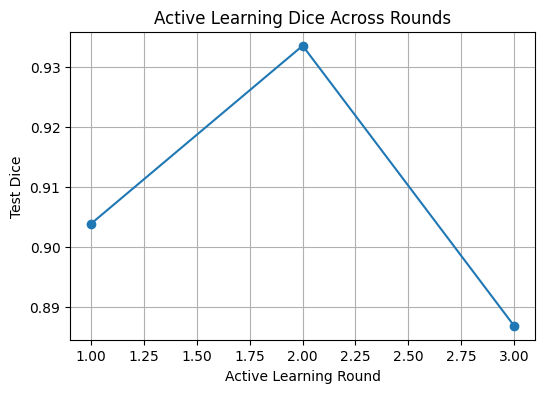

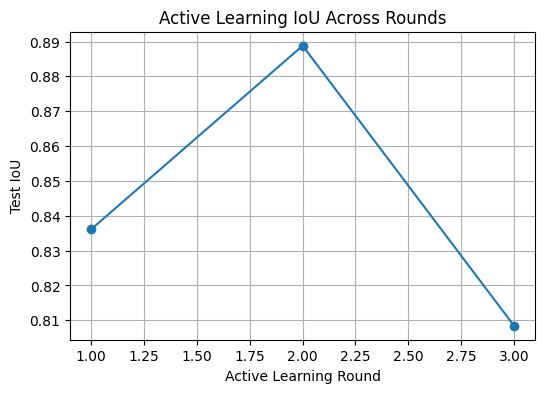

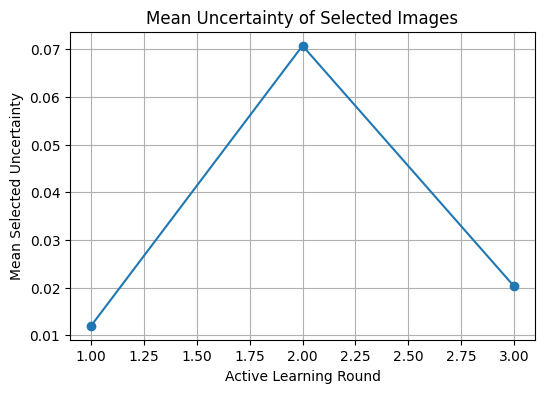

In [88]:
# %% =========================================================
# cell 26. visualize active learning performance
# purpose:
# plot how segmentation performance changes across active learning
# rounds on the full dataset
# ============================================================

if len(active_history_df) > 0:
    plt.figure(figsize=(6, 4))
    plt.plot(active_history_df["round"], active_history_df["test_dice"], marker="o")
    plt.xlabel("Active Learning Round")
    plt.ylabel("Test Dice")
    plt.title("Active Learning Dice Across Rounds")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(active_history_df["round"], active_history_df["test_iou"], marker="o")
    plt.xlabel("Active Learning Round")
    plt.ylabel("Test IoU")
    plt.title("Active Learning IoU Across Rounds")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(active_history_df["round"], active_history_df["mean_selected_uncertainty"], marker="o")
    plt.xlabel("Active Learning Round")
    plt.ylabel("Mean Selected Uncertainty")
    plt.title("Mean Uncertainty of Selected Images")
    plt.grid(True)
    plt.show()

In [89]:
# %% =========================================================
# cell 27. inspect final active learning summary
# purpose:
# print a compact summary of the full active learning experiment
# ============================================================

print("final labeled size:", len(final_labeled_indices))
print("final unlabeled size:", len(final_unlabeled_indices))

print("\nactive learning round summary:")
print(
    active_history_df[
        [
            "round",
            "labeled_size",
            "unlabeled_size",
            "num_selected_this_round",
            "mean_selected_uncertainty",
            "test_loss",
            "test_dice",
            "test_iou"
        ]
    ]
)

final labeled size: 50
final unlabeled size: 487

active learning round summary:
   round  labeled_size  unlabeled_size  num_selected_this_round  \
0      1            20             517                       10   
1      2            30             507                       10   
2      3            40             497                       10   

   mean_selected_uncertainty  test_loss  test_dice  test_iou  
0                   0.011998   0.844974   0.903879  0.836142  
1                   0.070746   0.726958   0.933543  0.888789  
2                   0.020309   0.730692   0.886835  0.808449  
